In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import geopandas as gpd
import rasterio
from pathlib import Path
from dist_s1.data_models.data_utils import get_acquisition_datetime, get_track_number, get_burst_id
from rio_utils import get_pixel_values_at_lon_lat, get_row_col_from_profile, get_window_around_lon_lat, get_lat_lon_bounds_from_profile
import matplotlib.pyplot as plt
import numpy as np
from dist_plot import get_dist_s1_mpl_cmap
import matplotlib.dates as mdates
from earthaccess_utils import earthaccess_opera_geo_search, flatten_earthaccess_result, read_multiple_earthdata_urls
from dist_s1.constants import DIST_STATUS_CMAP
from dist_plot import add_dist_s1_colorbar
from distmetrics.despeckle import despeckle_rtc_arrs_with_tv
from shapely.geometry import box
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from shapely.geometry import Point
import pycountry
from tile_mate import get_raster_from_tiles
from matplotlib.colors import ListedColormap, BoundaryNorm
from rasterio.plot import show
from basemaps import get_basemap_for_matplotlib, get_basemap_for_rasterio
from dist_s1_enumerator import get_mgrs_burst_lut
from tqdm import tqdm
import img2pdf

/Users/cmarshak/miniforge3/envs/dist-s1-env/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [3]:
df_hard_sites = pd.read_csv('reference_tables/nochange_ALLsub_conf.csv')[['ID', 'changetype', 'latitude', 'longitude', 'MGRS', 'blockstratum']].copy()
df_hard_sites.head(10)

,ID,changetype,latitude,longitude,MGRS,blockstratum
0,40284_2,No change,6.280459,101.930309,47NRG,treelosswet
1,97785_11,No change,13.967708,13.657636,33PUR,waternew
2,97785_16,No change,14.032046,13.719761,33PUR,waternew
3,315306_4,No change,33.678199,58.431040,40SFC,gen
4,315306_7,No change,33.704156,58.500742,40SFC,gen
5,372152_4,No change,39.134897,115.474069,50SLJ,waternew
6,372152_16,No change,39.136468,115.470217,50SLJ,waternew
7,490359_7,No change,50.025252,35.728314,36UXA,oldcrop_short
8,490359_16,No change,49.971673,35.824452,36UXA,oldcrop_short
9,490359_18,No change,49.956851,35.823584,36UXA,oldcrop_short


# Parameters

In [4]:
SITE_ID = '913366_4'
PIXEL_BUFFER = 100

In [92]:
df_lc = pd.read_csv('selectedpointsLL_landcover.csv')
df_lc.head()

,ID,Block,subID,blockStratum,substratum,zone,x,y,centx,centy,long,lat,MGRS,GLAD_2023_landcover_code,GLAD_2023_landcover
0,30961_1,30961,1,treelossTF,3,33,372932.570128,545394.967628,372945,545385,13.854048,4.933158,33NUF,31,tree_cover
1,30961_2,30961,2,treelossTF,2,33,372728.616472,542585.990364,372735,542595,13.852197,4.907920,33NUF,35,tree_cover
2,30961_3,30961,3,treelossTF,1,33,373846.916077,547093.248106,373845,547095,13.862138,4.948639,33NUF,48,tree_cover
3,30961_4,30961,4,treelossTF,4,33,371390.914129,546069.082218,371385,546075,13.839969,4.939375,33NUF,48,tree_cover
4,30961_5,30961,5,treelossTF,3,33,374504.487544,546457.554880,374505,546465,13.868099,4.942951,33NUF,37,tree_cover


In [94]:
site_data = df_hard_sites[df_hard_sites.ID == SITE_ID].to_dict('records')[0]
MGRS_TILE_ID = site_data['MGRS']
LON = site_data['longitude']
LAT = site_data['latitude']
OBSERVED_CHANGE_TYPE = site_data['changetype']
STRATUM_CHANGE_TYPE = site_data['blockstratum']
UMD_LC = df_lc[df_lc.ID == SITE_ID].GLAD_2023_landcover.values[0]


# AOI

In [6]:
site_geo = Point(LON, LAT)
df_point_aoi = gpd.GeoDataFrame(geometry=[site_geo], crs='4326')

# Visualize Time Series

## DIST-S1

In [7]:
status_files = sorted(Path(f'dist-s1-data/{MGRS_TILE_ID}').rglob('OPERA*GEN-DIST-STATUS.tif'))
status_files[:3]

[PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240112T225435Z_20251001T124348Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240112T225435Z_20251001T124348Z_S1C_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240124T225434Z_20250930T194927Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240124T225434Z_20250930T194927Z_S1C_30_v0.1_GEN-DIST-STATUS.tif'),
 PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240205T225434Z_20250930T185906Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240205T225434Z_20250930T185906Z_S1C_30_v0.1_GEN-DIST-STATUS.tif')]

In [8]:
metric_files = sorted(Path(f'dist-s1-data/{MGRS_TILE_ID}').rglob('OPERA*GEN-METRIC.tif'))
metric_files[:3]

[PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240112T225435Z_20251001T124348Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240112T225435Z_20251001T124348Z_S1C_30_v0.1_GEN-METRIC.tif'),
 PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240124T225434Z_20250930T194927Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240124T225434Z_20250930T194927Z_S1C_30_v0.1_GEN-METRIC.tif'),
 PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240205T225434Z_20250930T185906Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240205T225434Z_20250930T185906Z_S1C_30_v0.1_GEN-METRIC.tif')]

In [9]:
acq_files = sorted(Path(f'dist-s1-data/{MGRS_TILE_ID}').rglob('OPERA*GEN-DIST-STATUS-ACQ.tif'))
acq_files[:3]

[PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240112T225435Z_20251001T124348Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240112T225435Z_20251001T124348Z_S1C_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240124T225434Z_20250930T194927Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240124T225434Z_20250930T194927Z_S1C_30_v0.1_GEN-DIST-STATUS-ACQ.tif'),
 PosixPath('dist-s1-data/17UPT/OPERA_L3_DIST-ALERT-S1_T17UPT_20240205T225434Z_20250930T185906Z_S1C_30_v0.1/OPERA_L3_DIST-ALERT-S1_T17UPT_20240205T225434Z_20250930T185906Z_S1C_30_v0.1_GEN-DIST-STATUS-ACQ.tif')]

In [10]:
dist_s1_dates = list(map(get_acquisition_datetime, status_files))
dist_s1_dates[:10]

[Timestamp('2024-01-12 22:54:35+0000', tz='UTC'),
 Timestamp('2024-01-24 22:54:34+0000', tz='UTC'),
 Timestamp('2024-02-05 22:54:34+0000', tz='UTC'),
 Timestamp('2024-02-17 22:54:34+0000', tz='UTC'),
 Timestamp('2024-02-29 22:54:34+0000', tz='UTC'),
 Timestamp('2024-03-12 22:54:34+0000', tz='UTC'),
 Timestamp('2024-03-24 22:54:34+0000', tz='UTC'),
 Timestamp('2024-04-05 22:54:35+0000', tz='UTC'),
 Timestamp('2024-04-17 22:54:35+0000', tz='UTC'),
 Timestamp('2024-04-29 22:54:35+0000', tz='UTC')]

### DIST-S1 TS

In [11]:
def read_pixel_value(tif_path: str) -> float:
    return get_pixel_values_at_lon_lat(tif_path, lon=LON, lat=LAT, buffer_pixels=0)[0][0, 0]

In [12]:
dist_status_ts = list(map(read_pixel_value, status_files))
dist_status_ts = list(map(int, dist_status_ts))
dist_status_ts[:3]

[0, 0, 0]

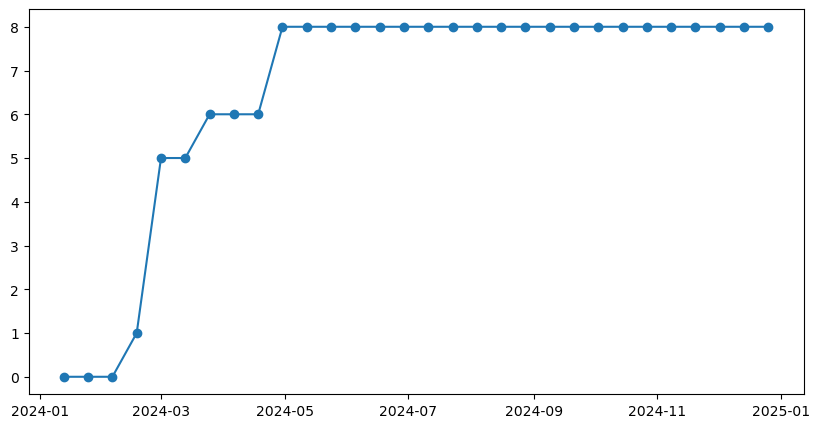

In [13]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(dist_s1_dates, dist_status_ts, marker='o')

### DIST S1 Status

In [14]:
dist_cmap, dist_norm = get_dist_s1_mpl_cmap()

In [15]:
def read_file_partial(tif_path: str) -> float:
    return get_pixel_values_at_lon_lat(tif_path, lon=LON, lat=LAT, buffer_pixels=PIXEL_BUFFER)[0]

def get_windowed_status_profile(tif_path: str) -> float:
    return get_pixel_values_at_lon_lat(tif_path, lon=LON, lat=LAT, buffer_pixels=PIXEL_BUFFER)[1]

In [16]:
def get_row_col_from_profile_p(profile):
    return get_row_col_from_profile(profile, LON, LAT)

center_dist_s1 = get_row_col_from_profile_p(get_windowed_status_profile(status_files[0]))
center_dist_s1

(100, 100)

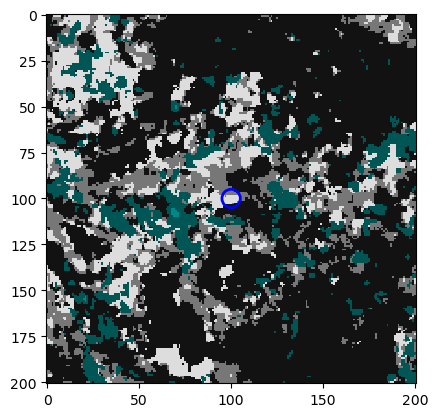

In [17]:
fig, ax = plt.subplots()
dist_status_image_ts = list(map(read_file_partial, status_files))
ax.imshow(dist_status_image_ts[-15], cmap=dist_cmap, norm=dist_norm, interpolation='none')

N =PIXEL_BUFFER
circle = plt.Circle((N, N), 5, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

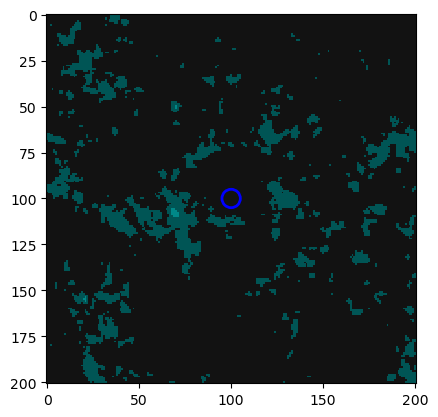

In [18]:
fig, ax = plt.subplots()
dist_acq_image_ts = list(map(read_file_partial, acq_files))
ax.imshow(dist_acq_image_ts[-15], cmap=dist_cmap, norm=dist_norm, interpolation='none')

N =PIXEL_BUFFER
circle = plt.Circle((N, N), 5, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

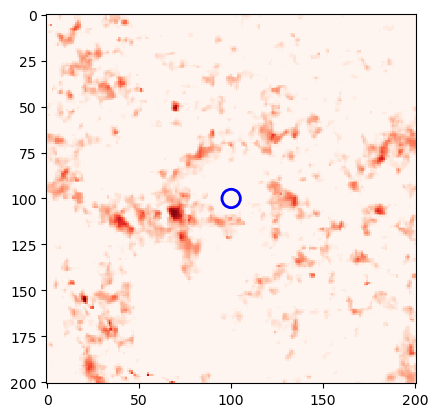

In [19]:
fig, ax = plt.subplots()
dist_metric_image_ts = list(map(read_file_partial, metric_files))
ax.imshow(dist_metric_image_ts[-15], interpolation='none', vmin=2, vmax=5, cmap='Reds')

N =PIXEL_BUFFER
circle = plt.Circle((N, N), 5, color='blue', fill=False, linewidth=2)
ax.add_patch(circle)

In [20]:
status_profile_window = get_windowed_status_profile(status_files[0])
status_profile_window

{'driver': 'GTiff', 'dtype': 'uint8', 'nodata': 255.0, 'width': 201, 'height': 201, 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 17N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-81],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32617"]]'), 'transform': Affine(30.0, 0.0, np.float64(686820.0),
       0.0, -30.0, np.float64(5760870.0)), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [21]:
with rasterio.open('status.tif', 'w', **status_profile_window) as ds:
    ds.write(dist_status_image_ts[-15], 1)
    ds.write_colormap(1, DIST_STATUS_CMAP)

# Bounding Box Geo

<Axes: >

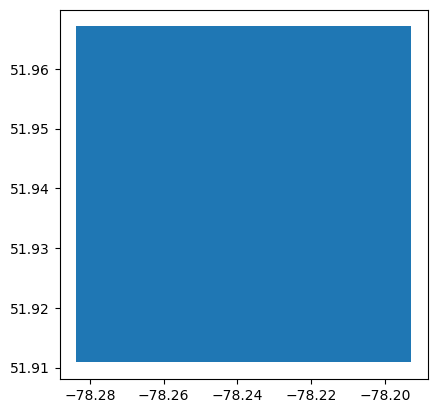

In [22]:
window_bbox = get_lat_lon_bounds_from_profile(status_profile_window)
df_window = gpd.GeoDataFrame(geometry=[box(*window_bbox)], crs='4326')
df_window.plot()

## Reference ts

In [23]:
df_ref_all = pd.read_csv('reference_tables/referenceTimeSeriesInterpolated16_16_goodFirst.csv')
df_ref_all.head()

,ID,overallLabel,Long,Lat,changetype,MGRS,2024-01-01,2024-01-02,2024-01-03,2024-01-04,...,2024-12-23,2024-12-24,2024-12-25,2024-12-26,2024-12-27,2024-12-28,2024-12-29,2024-12-30,2024-12-31,2025-01-01
0,30961_1,VLmin,13.854048,4.933158,Shifting cultivation,33NUF,noObs,noChange,noChange,noChange,...,VLmin,VLmin,VLmin,VLmin,VLmin,VLmin,VLmin,noObs,noObs,noObs
1,30961_2,VLmaj,13.852197,4.907920,Shifting cultivation,33NUF,noObs,noChange,noChange,noChange,...,VLmaj,VLmaj,VLmaj,VLmaj,VLmaj,VLmaj,VLmaj,noObs,noObs,noObs
2,30961_3,noChange,13.862138,4.948639,No Change,33NUF,noObs,noChange,noChange,noChange,...,noChange,noChange,noChange,noChange,noChange,noChange,noChange,noObs,noObs,noObs
3,30961_4,noChange,13.839969,4.939375,No Change,33NUF,noObs,noChange,noChange,noChange,...,noChange,noChange,noChange,noChange,noChange,noChange,noChange,noObs,noObs,noObs
4,30961_5,VLmaj,13.868099,4.942951,Shifting cultivation,33NUF,noObs,noChange,noChange,noChange,...,VLsub,VLsub,VLsub,VLsub,VLsub,VLsub,VLsub,noObs,noObs,noObs


In [24]:
def label_change(obs: str):
    if obs == 'noObs':
        return np.nan
    elif obs == 'noChange':
        return 0
    elif obs == 'change':
        return 1
    else:
        raise ValueError('label not recognized')

In [25]:
df_site_ts = df_ref_all[df_ref_all.ID == SITE_ID]
date_columns = [c for c in df_site_ts.columns if c not in ['ID', 'overallLabel', 'Long', 'Lat', 'changetype', 'MGRS']]
df_site_ts = df_site_ts[date_columns].transpose().copy()
df_site_ts.columns = ['observation']
df_site_ts = df_site_ts.reset_index(drop=False, names='date')
df_site_ts['date'] = pd.to_datetime(df_site_ts['date'], utc=True)
df_site_ts['observation_label'] = df_site_ts.observation.map(label_change)
df_site_ts.head()

,date,observation,observation_label
0,2024-01-01 00:00:00+00:00,noObs,NaN
1,2024-01-02 00:00:00+00:00,noObs,NaN
2,2024-01-03 00:00:00+00:00,noObs,NaN
3,2024-01-04 00:00:00+00:00,noObs,NaN
4,2024-01-05 00:00:00+00:00,noObs,NaN


(array([19875., 19905., 19936., 19967., 19997., 20028.]),
 [Text(19875.0, 0, 'Jun 2024'),
  Text(19905.0, 0, 'Jul 2024'),
  Text(19936.0, 0, 'Aug 2024'),
  Text(19967.0, 0, 'Sep 2024'),
  Text(19997.0, 0, 'Oct 2024'),
  Text(20028.0, 0, 'Nov 2024')])

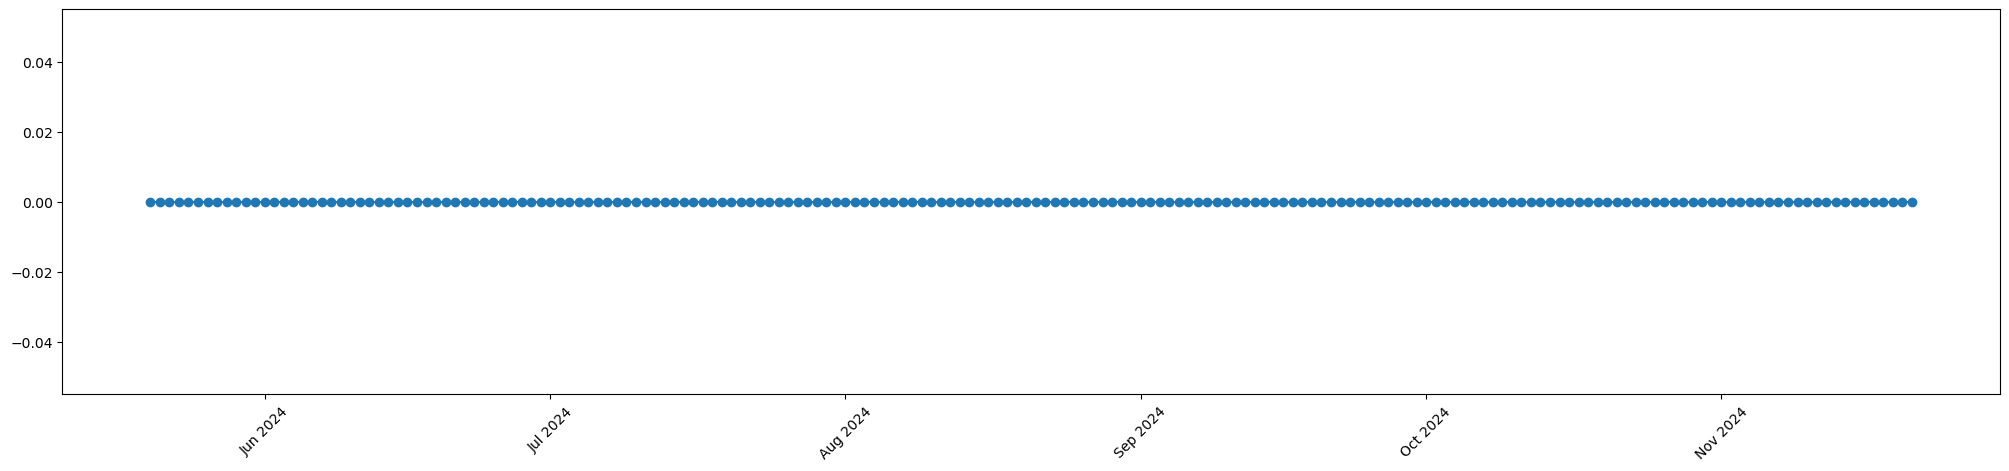

In [26]:
fig, ax = plt.subplots(figsize=(25, 5))
ax.plot(df_site_ts.date, df_site_ts.observation_label, marker='o')

#ax.xaxis.set_major_locator(mdates.DayLocator(interval=14))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=1))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))

plt.xticks(rotation=45)

# OPERA RTC Data

In [27]:
window_bbox = get_lat_lon_bounds_from_profile(status_profile_window)
window_bbox

(-78.2837056444656, 51.9108684445197, -78.19276294170808, 51.96707823603505)

In [28]:
window = get_window_around_lon_lat(status_files[0], lon=LON, lat=LAT, buffer_pixels=PIXEL_BUFFER)

In [29]:
results_rtc = earthaccess_opera_geo_search(window_bbox, '2022-01-01', '2025-01-01', 'RTC-S1')

In [30]:
flatten_earthaccess_result(results_rtc[0])

{'granule_id': 'OPERA_L2_RTC-S1_T033-069042-IW1_20220110T225435Z_20241218T144710Z_S1A_30_v1.0',
 'start_time': Timestamp('2022-01-10 22:54:35+0000', tz='UTC'),
 'end_time': Timestamp('2022-01-10 22:54:38+0000', tz='UTC'),
 'ascending_descending': 'ASCENDING',
 'beam_mode': 'IW',
 'bistatic_delay_correction': 'TRUE',
 'group_id': 'S1A_IWDV_0165_0171_041405_033',
 'look_direction': 'RIGHT',
 'noise_correction': 'TRUE',
 'opera_burst_id': 'T033_069042_IW1',
 'path_number': '33',
 'polarization': 'VV,VH',
 'post_processing_filter': 'FALSE',
 'processing_type': 'RTC',
 'product_version': '1.0',
 'radiometric_terrain_correction': 'TRUE',
 'static_tropo_correction': 'TRUE',
 'subswath_name': 'IW1',
 'wet_tropo_correction': 'FALSE',
 'url_h5': 'https://cumulus.asf.earthdatacloud.nasa.gov/OPERA/OPERA_L2_RTC-S1/OPERA_L2_RTC-S1_T033-069042-IW1_20220110T225435Z_20241218T144710Z_S1A_30/OPERA_L2_RTC-S1_T033-069042-IW1_20220110T225435Z_20241218T144710Z_S1A_30_v1.0.h5',
 'url_vh': 'https://cumulus.asf

In [31]:
df_lut = get_mgrs_burst_lut()
df_lut.head()

,jpl_burst_id,mgrs_tile_id,track_number,acq_group_id_within_mgrs_tile,orbit_pass,area_per_acq_group_km2,n_bursts_per_acq_group
0,T058-123813-IW3,01FBE,58,0,DESCENDING,3491,3
1,T058-123814-IW3,01FBE,58,0,DESCENDING,3491,3
2,T058-123815-IW3,01FBE,58,0,DESCENDING,3491,3
3,T081-173674-IW1,01FBE,81,1,ASCENDING,3572,2
4,T081-173675-IW1,01FBE,81,1,ASCENDING,3572,2


In [32]:
metadata = list(map(flatten_earthaccess_result, results_rtc))
df_rtc = gpd.GeoDataFrame(metadata)
df_rtc = df_rtc[df_rtc.contains(site_geo)].reset_index(drop=True)
df_rtc['track_number'] = df_rtc.granule_id.map(get_track_number)
df_rtc['mgrs_tile_id'] = MGRS_TILE_ID
df_rtc['jpl_burst_id'] = df_rtc.granule_id.map(get_burst_id)
df_rtc['acq_time'] = df_rtc.granule_id.map(lambda x: pd.to_datetime(get_acquisition_datetime(x)))
df_rtc['overlap_area'] = df_rtc.geometry.intersection(df_window.geometry).area
df_rtc['repeat_pass_int'] = (df_rtc.start_time - pd.Timestamp('2014-01-01', tz='UTC')).dt.total_seconds() // (60 * 60 * 24 * 6)
df_rtc = df_rtc.merge(df_lut[['jpl_burst_id', 'acq_group_id_within_mgrs_tile', 'mgrs_tile_id']], on=['jpl_burst_id', 'mgrs_tile_id'], how='left')
df_rtc = df_rtc.sort_values(by=['repeat_pass_int', 'overlap_area'], ascending=False)
print(df_rtc.shape)
df_rtc = df_rtc.groupby(['repeat_pass_int', 'acq_group_id_within_mgrs_tile']).first().reset_index()
print(df_rtc.shape)
df_rtc.head()

(86, 32)
(83, 32)


/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_97366/3577463840.py:8: UserWarning: The indices of the left and right GeoSeries' are not equal, and therefore they will be aligned (reordering and/or introducing missing values) before executing the operation. If this alignment is the desired behaviour, you can silence this warning by passing 'align=True'. If you don't want alignment and protect yourself of accidentally aligning, you can pass 'align=False'.
  df_rtc['overlap_area'] = df_rtc.geometry.intersection(df_window.geometry).area
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_97366/3577463840.py:8: UserWarning: CRS mismatch between the CRS of left geometries and the CRS of right geometries.
Use `to_crs()` to reproject one of the input geometries to match the CRS of the other.

Left CRS: None
Right CRS: EPSG:4326

  df_rtc['overlap_area'] = df_rtc.geometry.intersection(df_window.geometry).area


,repeat_pass_int,acq_group_id_within_mgrs_tile,granule_id,start_time,end_time,ascending_descending,beam_mode,bistatic_delay_correction,group_id,look_direction,...,url_vh,url_vv,url_mask,geometry,beam_mode_desc,track_number,mgrs_tile_id,jpl_burst_id,acq_time,overlap_area
0,488.0,1,OPERA_L2_RTC-S1_T033-069042-IW1_20220110T22543...,2022-01-10 22:54:35+00:00,2022-01-10 22:54:38+00:00,ASCENDING,IW,TRUE,S1A_IWDV_0165_0171_041405_033,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-78.46517 51.84065, -77.77384 51.925...",None,33,17UPT,T033-069042-IW1,2022-01-10 22:54:35+00:00,0.005112
1,490.0,1,OPERA_L2_RTC-S1_T033-069042-IW1_20220122T22543...,2022-01-22 22:54:35+00:00,2022-01-22 22:54:38+00:00,ASCENDING,IW,TRUE,S1A_IWDV_0165_0171_041580_033,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-78.46395 51.8403, -77.77263 51.9250...",None,33,17UPT,T033-069042-IW1,2022-01-22 22:54:35+00:00,NaN
2,492.0,1,OPERA_L2_RTC-S1_T033-069042-IW1_20220203T22543...,2022-02-03 22:54:34+00:00,2022-02-03 22:54:37+00:00,ASCENDING,IW,TRUE,S1A_IWDV_0165_0171_041755_033,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-78.46319 51.84046, -77.77188 51.925...",None,33,17UPT,T033-069042-IW1,2022-02-03 22:54:34+00:00,NaN
3,494.0,1,OPERA_L2_RTC-S1_T033-069042-IW1_20220215T22543...,2022-02-15 22:54:34+00:00,2022-02-15 22:54:37+00:00,ASCENDING,IW,TRUE,S1A_IWDV_0165_0171_041930_033,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-78.4632 51.84077, -77.77193 51.9255...",None,33,17UPT,T033-069042-IW1,2022-02-15 22:54:34+00:00,NaN
4,496.0,1,OPERA_L2_RTC-S1_T033-069042-IW1_20220227T22543...,2022-02-27 22:54:34+00:00,2022-02-27 22:54:37+00:00,ASCENDING,IW,TRUE,S1A_IWDV_0165_0171_042105_033,RIGHT,...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,https://cumulus.asf.earthdatacloud.nasa.gov/OP...,"POLYGON ((-78.46311 51.84043, -77.77186 51.925...",None,33,17UPT,T033-069042-IW1,2022-02-27 22:54:34+00:00,NaN


<Axes: >

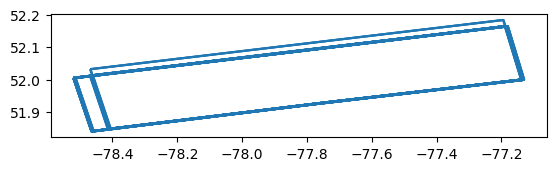

In [33]:
df_rtc.boundary.plot()

In [34]:
out_data = read_multiple_earthdata_urls(df_rtc.url_vv.tolist(), extent=window_bbox, max_workers=10)
vv_arrs, vv_profs = out_data

100%|██████████| 83/83 [00:19<00:00,  4.16it/s]


In [35]:
out_data = read_multiple_earthdata_urls(df_rtc.url_vh.tolist(), extent=window_bbox, max_workers=10)
vh_arrs, vh_profs = out_data

100%|██████████| 83/83 [00:17<00:00,  4.86it/s]


In [36]:
vv_arrs_tv = despeckle_rtc_arrs_with_tv(vv_arrs, preserve_exterior_mask=False, n_jobs=10)
vh_arrs_tv = despeckle_rtc_arrs_with_tv(vh_arrs, preserve_exterior_mask=False, n_jobs=10)

Despeckling: 100%|██████████| 83/83 [00:04<00:00, 17.91it/s]


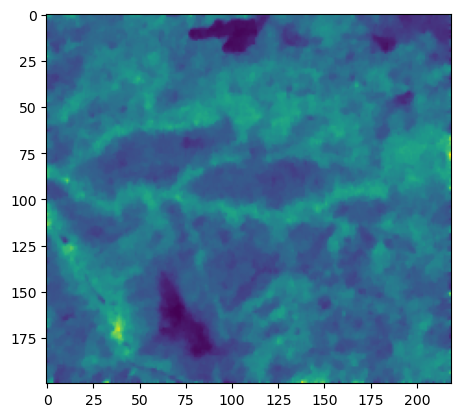

In [37]:
plt.imshow(vv_arrs_tv[0])

In [38]:
vh_profs[0]

{'driver': 'GTiff', 'dtype': 'float32', 'nodata': nan, 'width': np.int64(219), 'height': np.int64(200), 'count': 1, 'crs': CRS.from_wkt('PROJCS["WGS 84 / UTM zone 18N",GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4326"]],PROJECTION["Transverse_Mercator"],PARAMETER["latitude_of_origin",0],PARAMETER["central_meridian",-75],PARAMETER["scale_factor",0.9996],PARAMETER["false_easting",500000],PARAMETER["false_northing",0],UNIT["metre",1,AUTHORITY["EPSG","9001"]],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","32618"]]'), 'transform': Affine(30.0, 0.0, np.float64(274140.0),
       0.0, -30.0, np.float64(5762220.0)), 'blockxsize': 512, 'blockysize': 512, 'tiled': True, 'compress': 'deflate', 'interleave': 'band'}

In [39]:
def get_row_col_from_profile_p(profile):
    return get_row_col_from_profile(profile, LON, LAT)

centers_rtc = list(map(get_row_col_from_profile_p, vh_profs))
centers_rtc[-3:]

[(100, 109), (100, 109), (100, 109)]

In [40]:
vv_pixel_ts = np.array([vv[c] for (vv, c) in zip(vv_arrs_tv, centers_rtc)])
vh_pixel_ts = np.array([vh[c] for (vh, c) in zip(vh_arrs_tv, centers_rtc)])
rtc_dates = df_rtc.acq_time

<>:6: SyntaxWarning: invalid escape sequence '\g'
<>:6: SyntaxWarning: invalid escape sequence '\g'
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_97366/1358849417.py:6: SyntaxWarning: invalid escape sequence '\g'
  ax_vv.set_ylabel('$\gamma_{VV}$', color='blue')


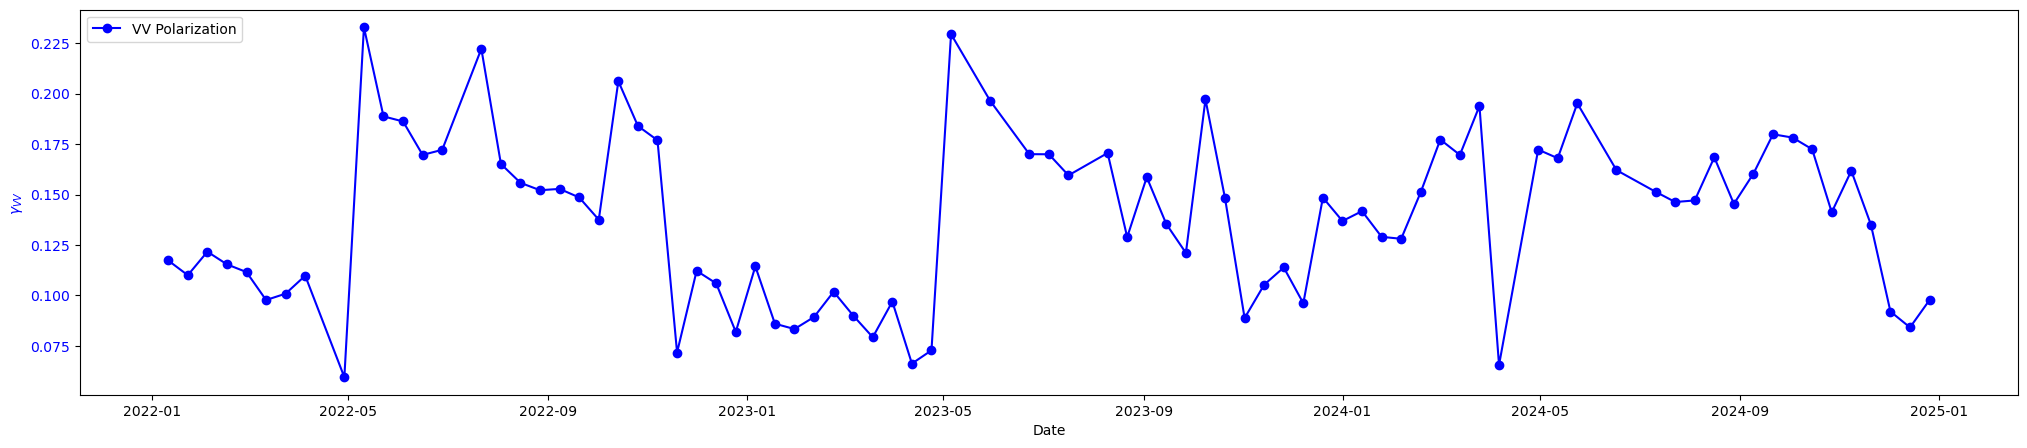

In [41]:
import matplotlib.pyplot as plt

fig, ax_vv = plt.subplots(figsize=(25, 5))

vv_ln = ax_vv.plot(rtc_dates, vv_pixel_ts, marker='o', color='blue', label='VV Polarization')
ax_vv.set_ylabel('$\gamma_{VV}$', color='blue')
ax_vv.tick_params(axis='y', labelcolor='blue')
ax_vv.set_xlabel('Date')

ax_vv.legend( loc='upper left')


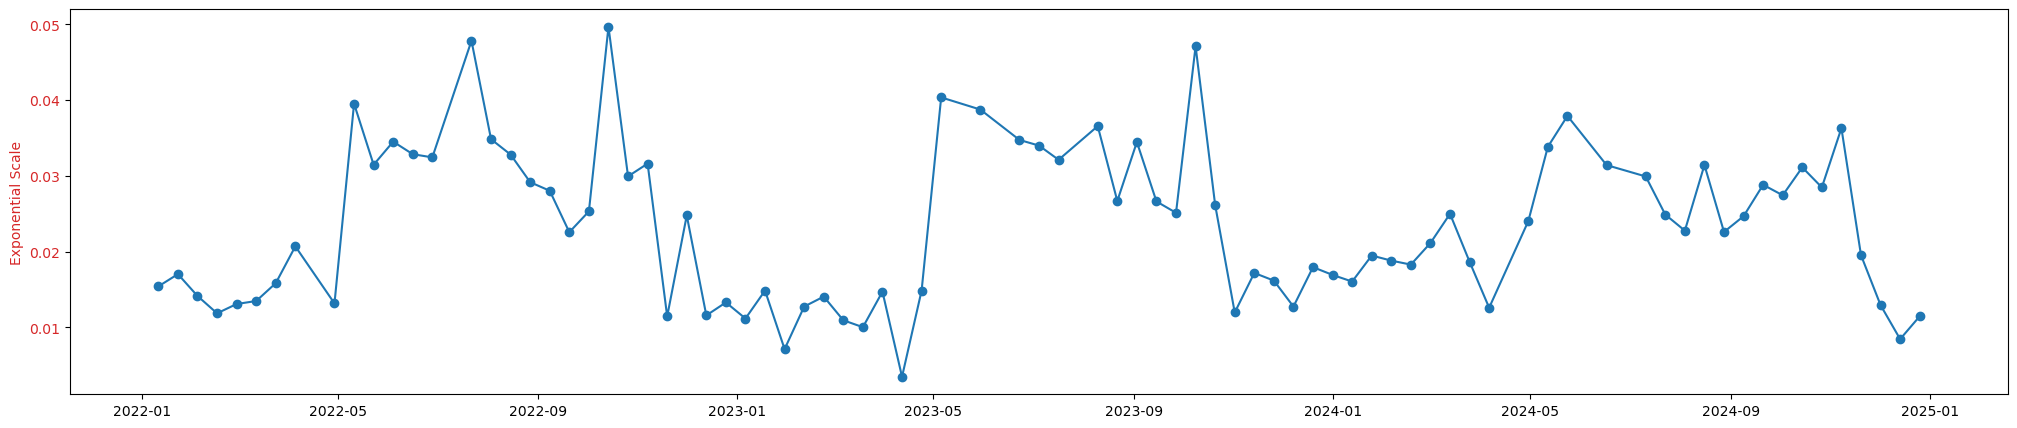

In [42]:
fig, ax_vh = plt.subplots(figsize=(25, 5))

vh_ln = ax_vh.plot(rtc_dates, vh_pixel_ts, marker='o')
ax_vh.set_ylabel('Exponential Scale', color='tab:red')
ax_vh.tick_params(axis='y', labelcolor='tab:red')


In [43]:
# vv_pixel_ts = np.array([vv[c] for (vv, c) in zip(vv_arrs_tv, centers_rtc)])
# vh_pixel_ts = np.array([vh[c] for (vh, c) in zip(vh_arrs_tv, centers_rtc)])

# vv_pixel_ts_obs = vv_pixel_ts[~np.isnan(vv_pixel_ts)]
# vh_pixel_ts_obs = vh_pixel_ts[~np.isnan(vh_pixel_ts)]

# rtc_dates = df_rtc.start_time.values
# rtc_dates_obs = rtc_dates[~np.isnan(vv_pixel_ts)]
# rtc_dates_nans = rtc_dates[np.isnan(vv_pixel_ts)]

# rtc_nans = np.zeros(np.isnan(vv_pixel_ts).sum())

# DIST-HLS


In [44]:
results_dist_hls = earthaccess_opera_geo_search(window_bbox, '2024-01-01', '2025-01-01', 'DIST-HLS-ALERT')

In [45]:
dict(results_dist_hls[0])

{'meta': {'concept-type': 'granule',
  'concept-id': 'G2874697663-LPCLOUD',
  'revision-id': 1,
  'native-id': 'OPERA_L3_DIST-ALERT-HLS_T17UPT_20240118T160751Z_20240208T144954Z_L9_30_v1',
  'collection-concept-id': 'C2746980408-LPCLOUD',
  'provider-id': 'LPCLOUD',
  'format': 'application/vnd.nasa.cmr.umm+json',
  'revision-date': '2024-02-23T18:19:39.805Z'},
 'umm': {'TemporalExtent': {'RangeDateTime': {'BeginningDateTime': '2024-01-18T16:07:51.392828Z',
    'EndingDateTime': '2024-01-18T16:07:51.392828Z'}},
  'GranuleUR': 'OPERA_L3_DIST-ALERT-HLS_T17UPT_20240118T160751Z_20240208T144954Z_L9_30_v1',
  'AdditionalAttributes': [{'Name': 'Input_DIST-ALERT_granule',
    'Values': ['OPERA_L3_DIST-ALERT-HLS_T17UPT_20240117T161329Z_20240208T144926Z_L8_30_v1']},
   {'Name': 'BaselineCalendarWindow', 'Values': ['+/- 15 days']},
   {'Name': 'BaselineYearWindow', 'Values': ['3']},
   {'Name': 'BaselineImageIds',
    'Values': ['HLS.S30.T17UPT.2023009T162639.v2.0',
     'HLS.S30.T17UPT.2021006T16

In [46]:
def get_mgrs_tile_id(granule_id: str) -> str:
    return granule_id.split('_')[3]

In [47]:
metadata = list(map(flatten_earthaccess_result, results_dist_hls))
df_dist_hls = gpd.GeoDataFrame(metadata)
df_dist_hls = df_dist_hls[df_dist_hls.mgrs_tile_id == MGRS_TILE_ID].reset_index(drop=True)
df_dist_hls = df_dist_hls.sort_values(by='start_time', ascending=True).reset_index(drop=True)
df_dist_hls.head()

,granule_id,start_time,end_time,input_dist-alert_granule,baselinecalendarwindow,baselineyearwindow,baselineimageids,validationlevel,hlsgranuleur,sensor_product_id,...,url_gen-dist-status,url_gen-anom,url_gen-anom-max,url_gen-dist-conf,url_gen-dist-date,url_gen-dist-count,url_gen-dist-dur,url_gen-last-date,url_data-mask,geometry
0,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240118T160751...,2024-01-18 16:07:51.392828+00:00,2024-01-18 16:07:51.392828+00:00,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240117T161329...,+/- 15 days,3,"HLS.S30.T17UPT.2023009T162639.v2.0,HLS.S30.T17...",1,HLS.L30.T17UPT.2024018T160751.v2.0,LC09_L1TP_019024_20240118_20240118_02_T1,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((-77.98918 51.32453, -77.92224 52.310..."
1,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240121T161559...,2024-01-21 16:19:00.433790+00:00,2024-01-21 16:19:00.433790+00:00,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240118T160751...,+/- 15 days,3,"HLS.S30.T17UPT.2023009T162639.v2.0,HLS.S30.T17...",1,HLS.S30.T17UPT.2024021T161559.v2.0,S2B_MSIL1C_20240121T161559_N0510_R140_T17UPT_2...,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((-77.98875 51.32452, -77.92224 52.310..."
2,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240129T162531...,2024-01-29 16:28:53.774150+00:00,2024-01-29 16:28:53.774150+00:00,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240125T161335...,+/- 15 days,3,"HLS.L30.T17UPT.2021040T161328.v2.0,HLS.S30.T17...",1,HLS.S30.T17UPT.2024029T162531.v2.0,S2A_MSIL1C_20240129T162531_N0510_R040_T17UPT_2...,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((-77.98875 51.32452, -77.92224 52.310..."
3,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240203T160753...,2024-02-03 16:07:53.977204+00:00,2024-02-03 16:07:53.977204+00:00,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240202T161350...,+/- 15 days,3,"HLS.S30.T17UPT.2021049T162329.v2.0,HLS.L30.T17...",1,HLS.L30.T17UPT.2024034T160753.v2.0,LC09_L1TP_019024_20240203_20240203_02_T2,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,"POLYGON ((-77.98875 51.32452, -77.92224 52.310..."
4,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240203T162459...,2024-02-03 16:28:56.384250+00:00,2024-02-03 16:28:56.384250+00:00,OPERA_L3_DIST-ALERT-HLS_T17UPT_20240203T160753...,+/- 15 days,3,"HLS.S30.T17UPT.2021049T162329.v2.0,HLS.L30.T17...",1,HLS.S30.T17UPT.2024034T162459.v2.0,S2B_MSIL1C_20240203T162459_N0510_R040_T17UPT_2...,...,https://data.lpdaac.earthdatacloud.nasa.gov/lp...,https

In [48]:
df_dist_hls.columns

Index(['granule_id', 'start_time', 'end_time', 'input_dist-alert_granule',
       'baselinecalendarwindow', 'baselineyearwindow', 'baselineimageids',
       'validationlevel', 'hlsgranuleur', 'sensor_product_id',
       'spatial_coverage', 'mgrs_tile_id', 'hls_processing_time',
       'sensing_time', 'horizontal_cs_code', 'horizontal_cs_name', 'ulx',
       'uly', 'url_veg-dist-status', 'url_veg-ind', 'url_veg-anom',
       'url_veg-hist', 'url_veg-anom-max', 'url_veg-dist-conf',
       'url_veg-dist-date', 'url_veg-dist-count', 'url_veg-dist-dur',
       'url_veg-last-date', 'url_gen-dist-status', 'url_gen-anom',
       'url_gen-anom-max', 'url_gen-dist-conf', 'url_gen-dist-date',
       'url_gen-dist-count', 'url_gen-dist-dur', 'url_gen-last-date',
       'url_data-mask', 'geometry'],
      dtype='object')

In [49]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_gen-dist-status'].tolist(), extent=window_bbox, max_workers=10)
hls_gen_status_arrs, gen_status_profs = out_data

100%|██████████| 116/116 [00:23<00:00,  4.91it/s]


In [50]:
df_dist_hls['url_veg-dist-status'].tolist()[6]

'https://data.lpdaac.earthdatacloud.nasa.gov/lp-prod-protected/OPERA_L3_DIST-ALERT-HLS_V1/OPERA_L3_DIST-ALERT-HLS_T17UPT_20240218T162331Z_20240221T201045Z_S2A_30_v1/OPERA_L3_DIST-ALERT-HLS_T17UPT_20240218T162331Z_20240221T201045Z_S2A_30_v1_VEG-DIST-STATUS.tif'

In [51]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_veg-dist-status'].tolist(), extent=window_bbox, max_workers=5)
hls_veg_status_arrs, _ = out_data

100%|██████████| 116/116 [00:43<00:00,  2.69it/s]


In [52]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_gen-anom'].tolist(), extent=window_bbox, max_workers=5)
hls_gen_anom_arrs, _ = out_data

100%|██████████| 116/116 [00:40<00:00,  2.85it/s]


In [53]:
out_data = read_multiple_earthdata_urls(df_dist_hls['url_veg-anom'].tolist(), extent=window_bbox, max_workers=5)
hls_veg_anom_arrs, _ = out_data

100%|██████████| 116/116 [00:37<00:00,  3.06it/s]


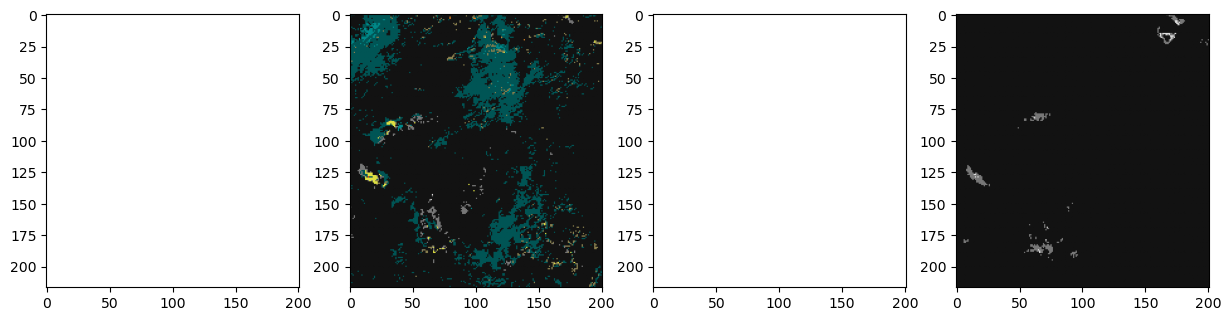

In [54]:
fig, ax = plt.subplots(1, 4, figsize=(15, 10))

veg_anom_arr_plot = np.ma.masked_equal(hls_veg_anom_arrs[10], 255)
ax[0].imshow(veg_anom_arr_plot, vmin=0, vmax=100)
ax[1].imshow(hls_veg_status_arrs[10], cmap=dist_cmap, norm=dist_norm)

gen_anom_arr_plot = np.ma.masked_equal(hls_gen_anom_arrs[10], -1)
ax[2].imshow(gen_anom_arr_plot, vmin=0, vmax=100)
ax[3].imshow(hls_gen_status_arrs[10], cmap=dist_cmap, norm=dist_norm)

In [55]:
def get_row_col_from_profile_p(profile):
    return get_row_col_from_profile(profile, LON, LAT)

centers_dist_hls = list(map(get_row_col_from_profile_p, gen_status_profs))
centers_dist_hls[-3:]

[(108, 100), (108, 100), (108, 100)]

(-1.0, 9.0)

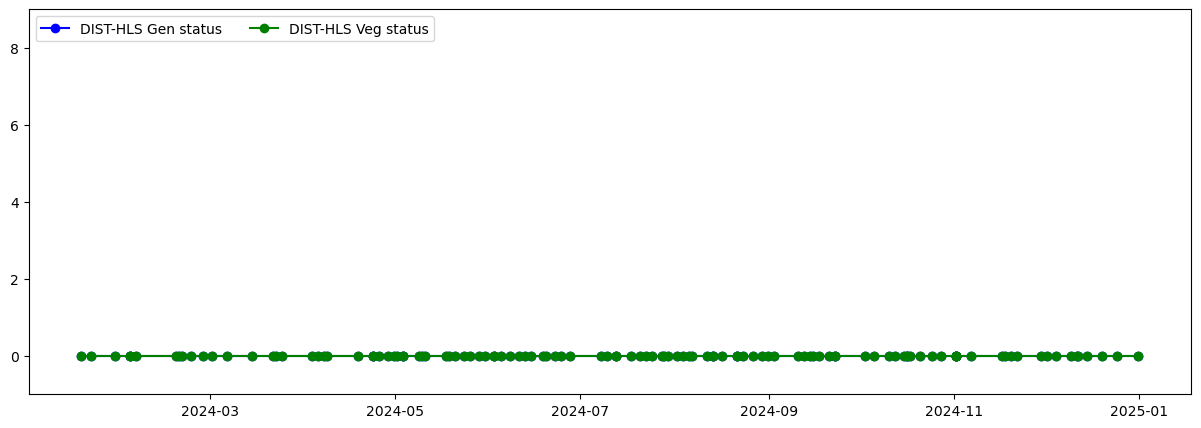

In [56]:
hls_veg_status_ts = np.array([vv[c] for (vv, c) in zip(hls_veg_status_arrs, centers_dist_hls)])
hls_gen_status_ts = np.array([vh[c] for (vh, c) in zip(hls_gen_status_arrs, centers_dist_hls)])

dist_hls_dates = pd.to_datetime(df_dist_hls.start_time)

fig, ax = plt.subplots(figsize=(15, 5))
ax.plot(dist_hls_dates, hls_gen_status_ts, marker='o', label='DIST-HLS Gen status', color='blue')
ax.plot(dist_hls_dates, hls_veg_status_ts, marker='o', label='DIST-HLS Veg status', color='green')
ax.legend(loc='upper left', ncol=4)
ax.set_ylim(-1, 9)

In [57]:
dist_hls_dates = df_dist_hls.start_time.tolist()

# Land Cover

In [58]:
X_esa, p_esa = get_raster_from_tiles(window_bbox, 
                                     tile_shortname='esa_world_cover_2021')

Reading tile imagery: 100%|██████████| 1/1 [00:01<00:00,  1.29s/it]


In [59]:
X_esa, p_esa = get_raster_from_tiles(window_bbox, 
                                     tile_shortname='esa_world_cover_2021')

Reading tile imagery: 100%|██████████| 1/1 [00:00<00:00,  1.09it/s]


In [60]:
legend_data = p_esa['tags']['legend'].split('\n')
legend_data = list(filter(lambda x: x, legend_data))
ticks = [int(d.split()[0]) for d in legend_data]
tick_labels = [' '.join(d.split()[1:]) for d in legend_data]

In [61]:
esa_dict = dict(zip(ticks, tick_labels))
esa_dict

{10: 'Tree cover',
 20: 'Shrubland',
 30: 'Grassland',
 40: 'Cropland',
 50: 'Built-up',
 60: 'Bare/sparse vegetation',
 70: 'Snow and ice',
 80: 'Permanent water bodies',
 90: 'Herbaceous wetland',
 95: 'Mangroves',
 100: 'Moss and lichen'}

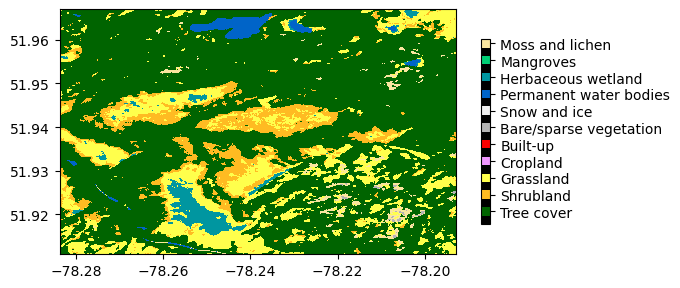

In [62]:
fig, ax = plt.subplots()

colormap = p_esa['colormap'][1]  # We store each colormap as a dictionary associated to its channel
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
im_data = show(X_esa[0, ...], 
               transform=p_esa['transform'], 
               cmap=cmap, 
               interpolation='none', 
               vmin=0, 
               vmax=255, 
               ax=ax)

im = im_data.get_images()[0]
bounds_fig = sorted([0] + [t - .5 for t in ticks] + [t + .5 for t in ticks])
cbar=fig.colorbar(im, 
                  ax=ax, 
                  shrink=0.5, 
                  pad=0.05, 
                  boundaries=bounds_fig, 
                  cmap=cmap,
                  ticks=np.array(ticks)
                 ) 
norm = BoundaryNorm(bounds_fig, cmap.N)
cbar.set_ticklabels(tick_labels)

In [63]:
legend_data

['10  Tree cover',
 '20  Shrubland',
 '30  Grassland',
 '40  Cropland',
 '50  Built-up',
 '60  Bare/sparse vegetation',
 '70  Snow and ice',
 '80  Permanent water bodies',
 '90  Herbaceous wetland',
 '95  Mangroves',
 '100 Moss and lichen']

In [64]:
from rasterio.transform import rowcol
r, c = rowcol(p_esa['transform'], LON, LAT)

esa_label = X_esa[0, r, c]
esa_class = esa_dict[esa_label]
print(f'{esa_label}: {esa_class}')

20: Shrubland


# Basemap Imagery

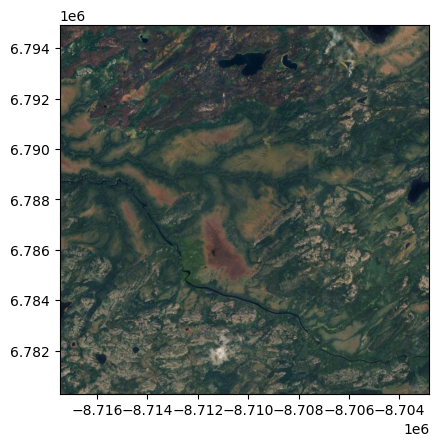

In [65]:
img, ext = get_basemap_for_matplotlib(*window_bbox, zoom='auto', source='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}')

plt.imshow(img, extent=ext)
plt.show()

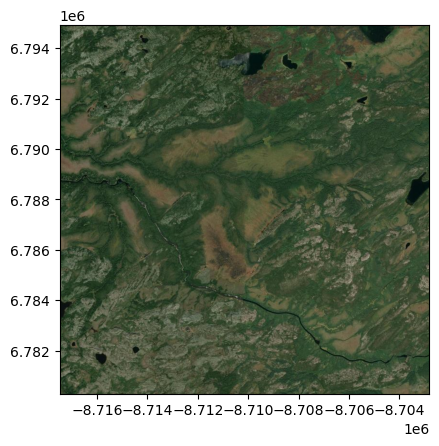

In [66]:
img, ext = get_basemap_for_matplotlib(*window_bbox, zoom='auto')

plt.imshow(img, extent=ext)
plt.show()

<Axes: >

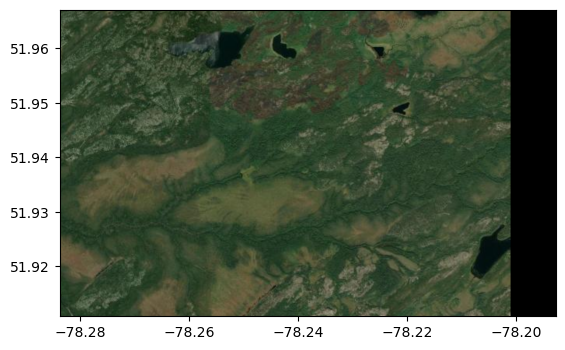

In [67]:
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
X_esri, p_esri = get_basemap_for_rasterio(*window_bbox, zoom='auto', dst_crs='4326', nodata=None)

X_esri = X_esri[:3, ...].astype(np.float32) / 255.
p_esri['dtype'] = np.float32
p_esri['count'] = 3
X_esri, p_esri = reproject_arr_to_match_profile(X_esri, p_esri, p_esa, resampling='bilinear')

fig, ax = plt.subplots()
show(X_esri, transform=p_esri['transform'], ax=ax)

<Axes: >

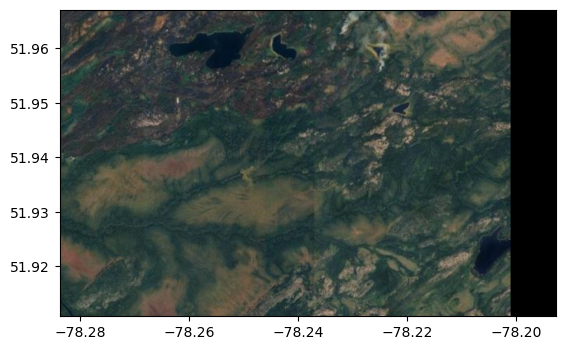

In [68]:
from dem_stitcher.rio_tools import reproject_arr_to_match_profile
X_goog, p_goog = get_basemap_for_rasterio(*window_bbox, zoom='auto', dst_crs='4326', source='https://mt1.google.com/vt/lyrs=s&x={x}&y={y}&z={z}', nodata=None)

X_goog = X_goog[:3, ...].astype(np.float32) / 255.
p_goog['dtype'] = np.float32
p_goog['count'] = 3
X_goog, p_goog = reproject_arr_to_match_profile(X_goog, p_goog, p_esa, resampling='bilinear')

fig, ax = plt.subplots()
show(X_goog, transform=p_goog['transform'], ax=ax)

# Location

In [69]:
import reverse_geocoder as rg

coordinates = (LON, LAT) # New York City
results = rg.search(coordinates) # Returns a list of dicts

print(f"City: {results[0]['name']}, Country: {results[0]['cc']}")

Loading formatted geocoded file...
City: Port-aux-Francais, Country: TF


# Final Images

## Create Img Directories

In [70]:
out_dir = Path('out')

site_dir = out_dir / SITE_ID

png_dir = site_dir / 'pngs'

png_dir.mkdir(exist_ok=True, parents=True)

## Location Panel

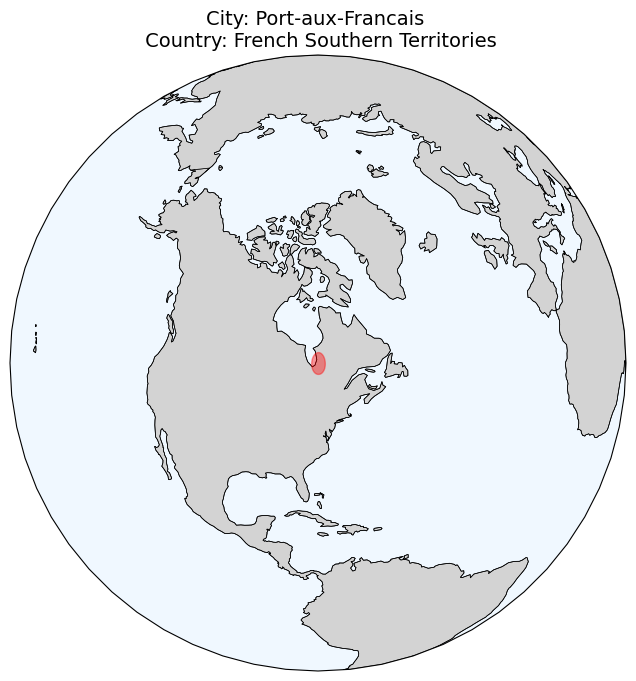

In [71]:
bbox_geom = box(*window_bbox).buffer(2)
center_lon, center_lat = bbox_geom.centroid.coords[0]
projection = ccrs.Orthographic(central_longitude=center_lon, central_latitude=center_lat)

fig = plt.figure(figsize=(8, 8))
ax = plt.axes(projection=projection)

ax.set_global() # Show the full sphere
ax.add_feature(cfeature.OCEAN, color='aliceblue')
ax.add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_geometries([bbox_geom], crs=ccrs.PlateCarree(), 
                  facecolor='red', alpha=0.4, edgecolor='red', linewidth=1)


country_ob = pycountry.countries.get(alpha_2=results[0]['cc'])
country_name = country_ob.name if country_ob else "Unknown Country"
ax.set_title(f"City: {results[0]['name']} \n Country: {country_name}", fontsize=14)
plt.show()

In [72]:
def plot_globe_in_mosaic_plot(fig, axs, ax_label):
    pos = axs[ax_label].get_subplotspec() 
    axs[ax_label].remove()               
    bbox_geom = box(*window_bbox).buffer(2)
    center_lon, center_lat = bbox_geom.centroid.coords[0]
    projection = ccrs.Orthographic(central_longitude=center_lon, central_latitude=center_lat)

    axs[ax_label] = fig.add_subplot(pos, projection=projection)
    
    axs[ax_label].set_global() # Show the full sphere
    axs[ax_label].add_feature(cfeature.OCEAN, color='aliceblue')
    axs[ax_label].add_feature(cfeature.LAND, edgecolor='black', facecolor='lightgray', linewidth=0.5)
    axs[ax_label].add_feature(cfeature.COASTLINE, linewidth=0.5)
    axs[ax_label].add_geometries([bbox_geom], crs=ccrs.PlateCarree(), 
                      facecolor='red', alpha=0.4, edgecolor='red', linewidth=1)
    
    
    country_ob = pycountry.countries.get(alpha_2=results[0]['cc'])
    country_name = country_ob.name if country_ob else "Unknown Country"
    axs[ax_label].set_title(f"City: {results[0]['name']} \n Country: {country_name}", fontsize=14)

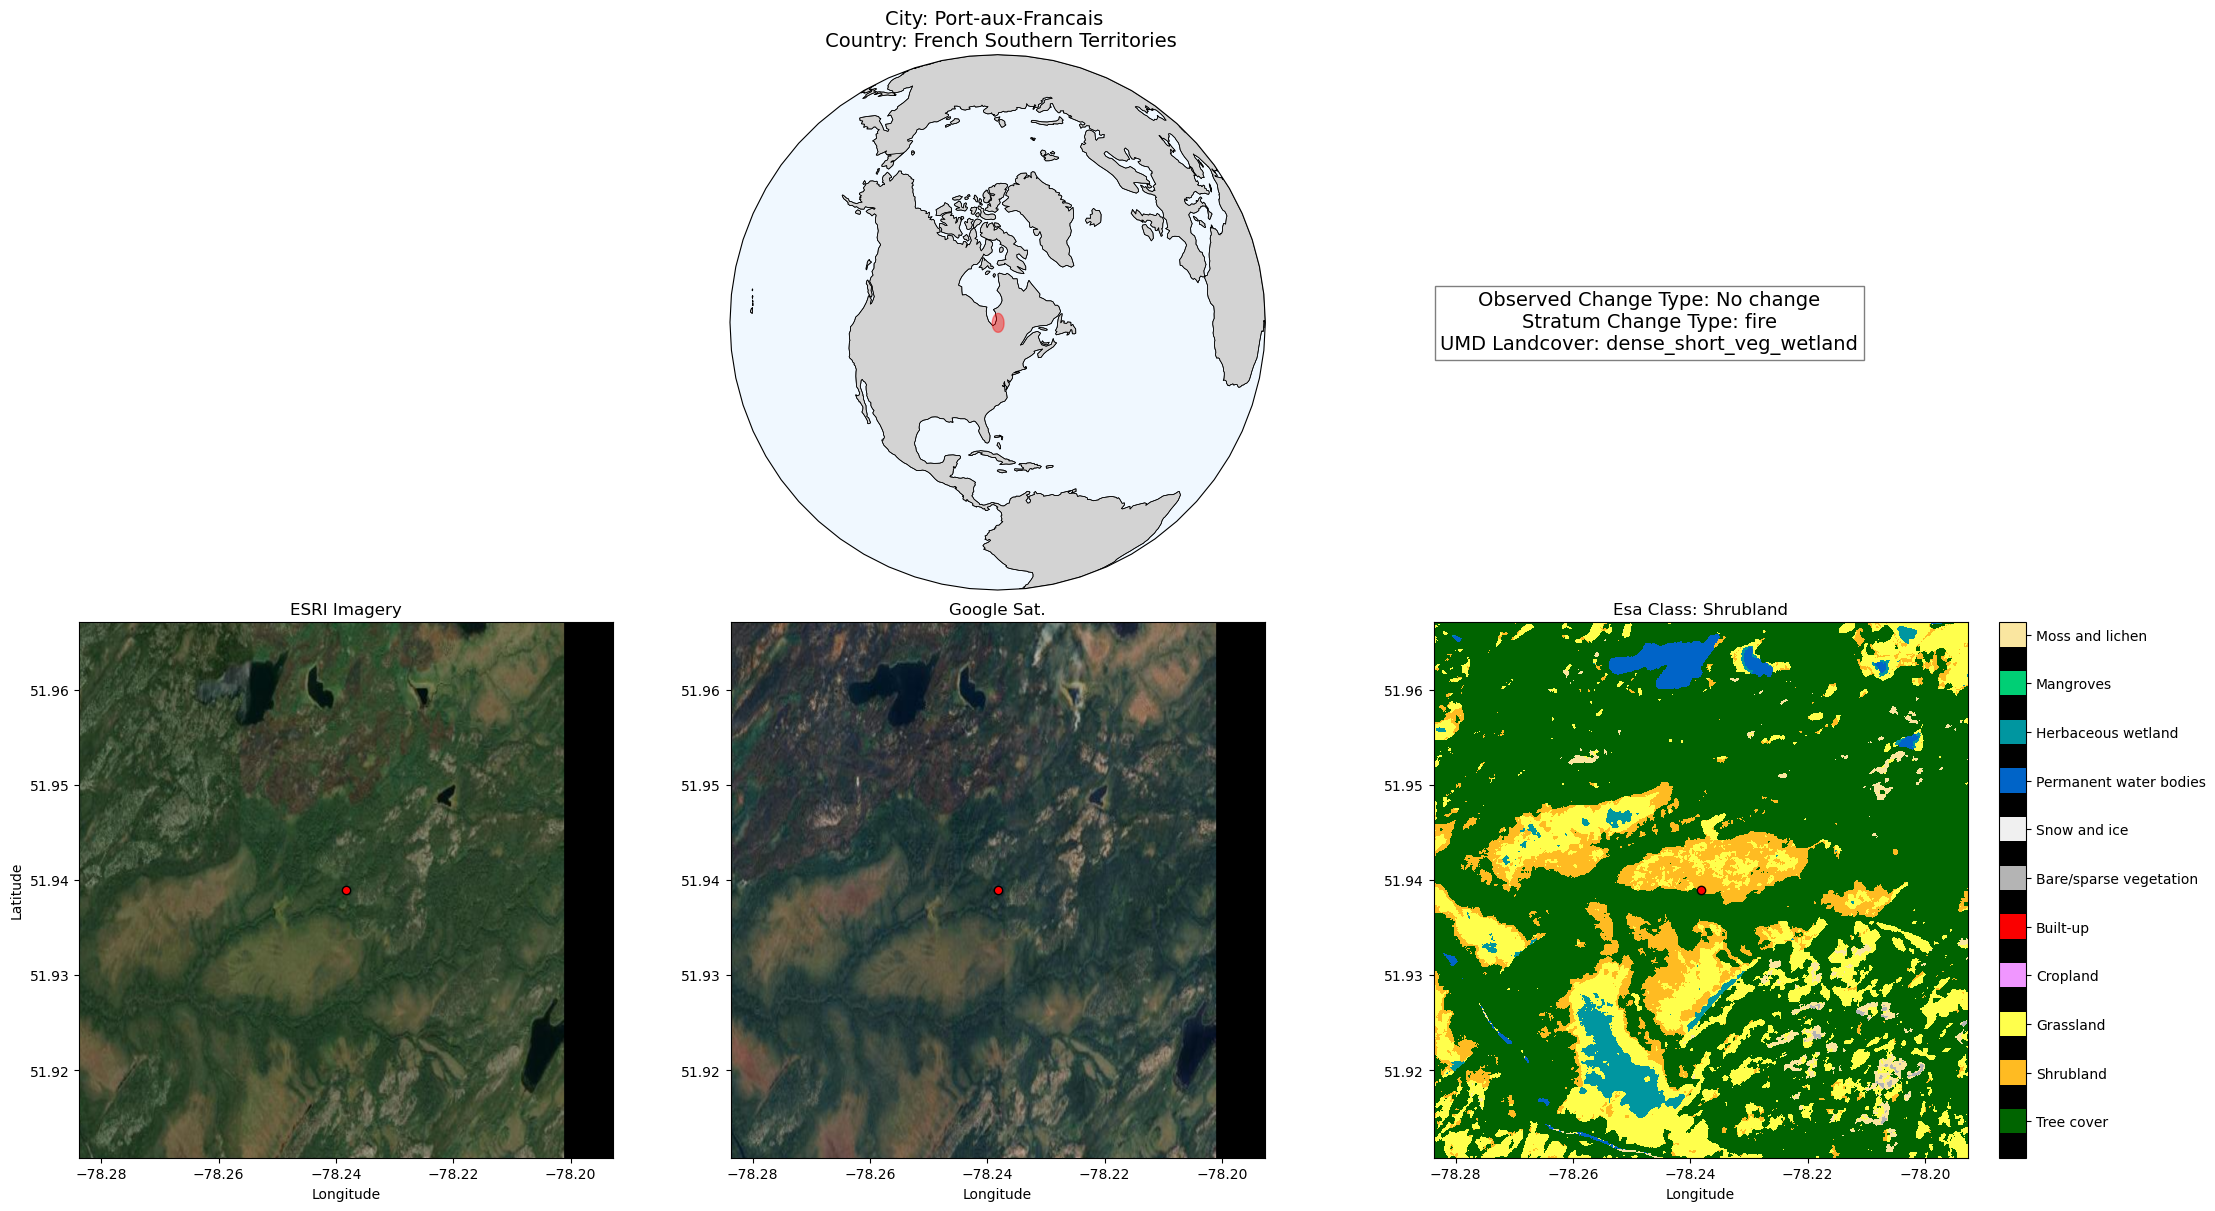

In [95]:
from basemaps import get_basemap_for_rasterio


layout = """
.aT
ABC
"""

fig, axd = plt.subplot_mosaic(
    layout, 
    constrained_layout=True, 
    figsize=(22, 12),
)

plot_globe_in_mosaic_plot(fig, axd, 'a')

for ax_lb in 'BC':
    axd[ax_lb].sharey(axd['A'])
    # axd[l].set_yticklabels([])
    axd[ax_lb].set_xlabel('Longitude')

axd['A'].set_ylabel('Latitude')
axd['A'].set_xlabel('Longitude')

show(X_esri, transform=p_esri['transform'], ax=axd['A'])
df_point_aoi.plot(ax=axd['A'], alpha=1, color='red', ec='black')
axd['A'].set_title('ESRI Imagery')

show(X_goog, transform=p_goog['transform'], ax=axd['B'])
df_point_aoi.plot(ax=axd['B'], alpha=1, color='red', ec='black')
axd['B'].set_title('Google Sat.')

colormap = p_esa['colormap'][1]  # We store each colormap as a dictionary associated to its channel
cmap = ListedColormap([np.array(colormap[key]) / 255 for key in range(256)])
im_data = show(X_esa[0, ...], 
               transform=p_esa['transform'], 
               cmap=cmap, 
               interpolation='none', 
               vmin=0, 
               vmax=255, 
               ax=axd['C'])

im = im_data.get_images()[0]
bounds_fig = sorted([0] + [t - .5 for t in ticks] + [t + .5 for t in ticks])
cbar=fig.colorbar(im, 
                  ax=axd['C'], 
                  #shrink=0.5, 
                  #pad=0.05, 
                  boundaries=bounds_fig, 
                  cmap=cmap,
                  ticks=np.array(ticks)
                 ) 
norm = BoundaryNorm(bounds_fig, cmap.N)
cbar.set_ticklabels(tick_labels)
df_point_aoi.plot(ax=axd['C'], alpha=1, color='red', ec='black', zorder=0)
axd['C'].set_title(f'Esa Class: {esa_class}')
axd['T'].axis('off')
text = f'Observed Change Type: {OBSERVED_CHANGE_TYPE}\nStratum Change Type: {STRATUM_CHANGE_TYPE}\nUMD Landcover: {UMD_LC}'
axd['T'].text(.5, .5, text, fontsize=14, bbox=dict(facecolor='white', alpha=0.5), ha='center', va='center')
fig.savefig(png_dir / '_location.png')

## DIST-S1 Panel

In [75]:
from dist_s1_enumerator import get_mgrs_table

In [76]:
df_mgrs = get_mgrs_table()
df_mgrs[df_mgrs.mgrs_tile_id == MGRS_TILE_ID].geometry.values[0].wkt

'POLYGON ((-79.5321158470521 52.3413550967726, -79.5638793748858 51.3544393897727, -77.9887458774251 51.3245233542209, -77.922242074712 52.3103669144162, -79.5321158470521 52.3413550967726))'

In [77]:
dist_s1_dates[:3]

[Timestamp('2024-01-12 22:54:35+0000', tz='UTC'),
 Timestamp('2024-01-24 22:54:34+0000', tz='UTC'),
 Timestamp('2024-02-05 22:54:34+0000', tz='UTC')]

In [78]:
def get_pre_post_rtc_indices(df_rtc: pd.DataFrame, status_date: pd.Timestamp, n_anniv=2) -> tuple[int, list[int]]:
    post_index_bool = (df_rtc.start_time - status_date).dt.total_seconds().abs() < 300
    if post_index_bool.sum() == 0:
        print('No RTC found within 5 minutes of status date; means no RTC overlapping the window bbox')
        return [None] * n_anniv, None
    post_index = post_index_bool.idxmax()
    burst_id = df_rtc.iloc[post_index].jpl_burst_id
    df_rtc_ts_burst = df_rtc[df_rtc.jpl_burst_id == burst_id]
    pre_indices = []
    for k in range(n_anniv):
        poss_ind_bool = (df_rtc_ts_burst.start_time < status_date - pd.Timedelta(days=365 * (k + 1)))
        if poss_ind_bool.sum() == 0:
            pre_index = None
        else:
            pre_index = poss_ind_bool.idxmin()
        pre_indices.append(pre_index)
    return pre_indices, post_index

for i in range(10):
    dt = dist_s1_dates[i]
    print('######')
    print(f'{i=}')
    print('dist date', dt)
    pre_indices, post_index = get_pre_post_rtc_indices(df_rtc, dt)
    p0, p1 = pre_indices
    print(p0, p1)
    if p1 is not None:
        print(df_rtc.iloc[p1].acq_time)
    if p0 is not None:
        print(df_rtc.iloc[p0].acq_time)
        print(df_rtc.iloc[post_index].acq_time)
    else:
        print('Probably should include track data in the dist information')
    print('######')




######
i=0
dist date 2024-01-12 22:54:35+00:00
29 1
2022-01-22 22:54:35+00:00
2023-01-17 22:54:40+00:00
2024-01-12 22:54:46+00:00
######
######
i=1
dist date 2024-01-24 22:54:34+00:00
30 2
2022-02-03 22:54:34+00:00
2023-01-29 22:54:41+00:00
2024-01-24 22:54:45+00:00
######
######
i=2
dist date 2024-02-05 22:54:34+00:00
31 3
2022-02-15 22:54:34+00:00
2023-02-10 22:54:40+00:00
2024-02-05 22:54:45+00:00
######
######
i=3
dist date 2024-02-17 22:54:34+00:00
32 4
2022-02-27 22:54:34+00:00
2023-02-22 22:54:39+00:00
2024-02-17 22:54:45+00:00
######
######
i=4
dist date 2024-02-29 22:54:34+00:00
33 5
2022-03-11 22:54:34+00:00
2023-03-06 22:54:40+00:00
2024-02-29 22:54:45+00:00
######
######
i=5
dist date 2024-03-12 22:54:34+00:00
34 6
2022-03-23 22:54:34+00:00
2023-03-18 22:54:40+00:00
2024-03-12 22:54:45+00:00
######
######
i=6
dist date 2024-03-24 22:54:34+00:00
35 7
2022-04-04 22:54:35+00:00
2023-03-30 22:54:40+00:00
2024-03-24 22:54:45+00:00
######
######
i=7
dist date 2024-04-05 22:54:35+

In [79]:
import matplotlib as mpl

def create_continuous_colorbar(fig, cax, cmap_str, vmin, vmax, label, 
                           tick_pos='right', label_ha='center', label_va='bottom'):
    norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
    sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap_str)
    
    cbar = fig.colorbar(sm, cax=cax)
    cbar.set_label(label, ha=label_ha, va=label_va)
    
    if tick_pos in ['left', 'right']:
        cbar.ax.yaxis.set_ticks_position(tick_pos)
        cbar.ax.yaxis.set_label_position(tick_pos)
    else:
        cbar.ax.xaxis.set_ticks_position(tick_pos)
        cbar.ax.xaxis.set_label_position(tick_pos)
        
    return cbar

In [80]:
from time_utils import get_last_index_before

dt = dist_s1_dates[-2]
idx = get_last_index_before(dist_hls_dates, dt)
dist_hls_dates[idx], dt, dt > dist_hls_dates[idx]

(Timestamp('2024-12-11 16:19:01.991800+0000', tz='UTC'),
 Timestamp('2024-12-13 22:54:32+0000', tz='UTC'),
 True)

In [81]:
vv_stack = np.stack([vv_arrs_tv[i] for i in range(len(vv_arrs_tv)) if vv_arrs_tv[i].shape == vv_arrs_tv[0].shape])
vh_stack = np.stack([vh_arrs_tv[i] for i in range(len(vh_arrs_tv)) if vh_arrs_tv[i].shape == vh_arrs_tv[0].shape])

vh_vmax = np.nanpercentile(vh_stack, 98)
vv_vmax = np.nanpercentile(vv_stack, 98)

In [82]:
def create_plot_panel(idx: int):
    layout = """
    .tttt.
    .ssss.
    .ZZZZ.
    .XXXX.
    .YYYY.
    012345
    S.mnoT
    AabcdC
    BwxyzD
    """


    dist_s1_index = idx
    dist_s1_date = dist_s1_dates[dist_s1_index]

    dist_hls_index = get_last_index_before(dist_hls_dates, dist_s1_date)
    if dist_hls_index is None:
        dist_hls_index = 0
    val_index = get_last_index_before(df_site_ts.date, dist_s1_date)

    pre_indices, post_index = get_pre_post_rtc_indices(df_rtc, dist_s1_date)

    pre_index, pre_index_earliest = pre_indices
    print(f'{pre_index=}')
    print(f'{post_index=}')

    diff_cmap='coolwarm'
    sar_cmap='viridis'
    metric_cmap='Reds'

    metric_vmin=2
    metric_vmax=5

    anom_vmax=25

    fig, axd = plt.subplot_mosaic(
        layout, 
        constrained_layout=True, 
        figsize=(12, 25),
        gridspec_kw={'width_ratios': [0.05, 1, 1, 1, 1, 0.05]}
    )
    fig.suptitle(f'Site ID: {SITE_ID} \n https://gladxfer.umd.edu/datasets/DIST-ALERT/2024sampleData/pagesS1NR/unit{SITE_ID}', fontsize=14)


    date_rtc_pre2 = df_rtc.acq_time[pre_index_earliest].date() if pre_index_earliest is not None else 'No Data'
    date_rtc_pre = df_rtc.acq_time[pre_index].date() if pre_index is not None else 'No Data'
    date_rtc_post = df_rtc.acq_time[post_index].date() if post_index is not None else 'No Data'

    ts_rtc_pre2 = df_rtc.acq_time[pre_index_earliest] if pre_index_earliest is not None else None
    ts_rtc_pre = df_rtc.acq_time[pre_index].date() if pre_index is not None else None
    ts_rtc_post = df_rtc.acq_time[post_index].date() if post_index is not None else None

    for (ax_label, arr, pol, vmax) in zip('XY', [vv_pixel_ts,vh_pixel_ts], ['VV', 'VH'], [vv_vmax, vh_vmax]):
        ax_ts = axd[ax_label]
        sar_ts = ax_ts.plot(rtc_dates, arr, marker='o', color='blue', label=f'{pol} Polarization')
        ax_ts.set_ylabel(f'{pol}')
        #nan_ln = ax_ts.plot(rtc_dates_nans, rtc_nans, marker='o', color='green', label='No observation')
        # ax_ts.set_ylim(vh_vmin - .01, vmax * 1.1)
        _, ymax = ax_ts.get_ylim()

        v_lns = []
        pre_present = False
        for color, label, date in [('purple', 'Pre-anniversary Date', ts_rtc_pre2), 
                                   ('purple', 'Pre-anniversary Date', ts_rtc_pre), 
                                   ('yellow', 'Current Date', ts_rtc_post)]:
            if date is not None:
                ln_val = ax_ts.vlines(date, 0, ymax, color=color, label=label, ls='--')
                if not pre_present and label == 'Pre-anniversary Date':
                    pre_present = True
                    v_lns.append(ln_val)
                if label != 'Pre-anniversary Date':
                    v_lns.append(ln_val)
        
        lns = sar_ts  + v_lns
        labs = [line.get_label() for line in lns]
        ax_ts.legend(lns, labs, loc='upper left', ncol=4)


    axd['t'].plot(dist_s1_dates, dist_status_ts, marker='o', color='blue', alpha=.5, label=f'DIST-S1 status (label = {dist_status_ts[dist_s1_index]})')
    axd['t'].plot(dist_s1_dates[dist_s1_index: dist_s1_index+1], 
                 dist_status_ts[dist_s1_index: dist_s1_index+1], marker='o', markersize=10, color='yellow', alpha=1)
    axd['t'].axvline(dist_s1_date, color='yellow', ls='--', alpha=1, linewidth=2, label=f'DIST-S1 ({dist_s1_date.date()})')
    axd['t'].set_ylabel('DIST-S1 Label')
    axd['t'].legend(loc='upper left', ncol=4)

    axd['s'].plot(dist_hls_dates, hls_gen_status_ts, marker='o', label=f'DIST-HLS Gen status (label = {hls_gen_status_ts[dist_hls_index]})', color='blue')
    axd['s'].plot(dist_hls_dates, hls_veg_status_ts, marker='o', label=f'DIST-HLS Veg status (label = {hls_veg_status_ts[dist_hls_index]})', color='green')
    axd['s'].plot(dist_hls_dates[dist_hls_index: dist_hls_index+1], 
                hls_gen_status_ts[dist_hls_index: dist_hls_index+1], marker='o', color='yellow', alpha=1, markersize=10)
    axd['s'].plot(dist_hls_dates[dist_hls_index: dist_hls_index+1], 
                hls_veg_status_ts[dist_hls_index: dist_hls_index+1], marker='o', color='yellow', alpha=1, markersize=10)
    axd['s'].axvline(dist_hls_dates[dist_hls_index], color='turquoise', ls='--', alpha=1, linewidth=2, label=f'Latest before DIST-S1 ({dist_hls_dates[dist_hls_index].date()})')
    axd['s'].legend(loc='upper left', ncol=4)

    axd['Z'].plot(df_site_ts.date, df_site_ts.observation_label, marker='o', label=f'Validation Label (label = {df_site_ts.observation_label.iloc[val_index]})')
    axd['Z'].plot(df_site_ts.date.iloc[val_index], df_site_ts.observation_label.iloc[val_index], marker='o', color='yellow', alpha=1, markersize=10)

    axd['Z'].set_ylabel('Validation Label')
    axd['Z'].axvline(df_site_ts.date.iloc[val_index], color='turquoise', ls='--', alpha=1, linewidth=2, label=f'Latest before DIST-S1 ({df_site_ts.date.iloc[val_index].date()})')
    axd['Z'].legend(loc='upper left', ncol=4)


    axd['s'].set_ylim(-1, 9)
    for ax_lb in 'tZ':
        axd[ax_lb].sharey(axd['t'])
    axd['s'].set_ylabel('DIST-HLS Label')

    create_continuous_colorbar(fig, axd['0'], metric_cmap, 0, anom_vmax, 'DIST-HLS Anomoly', tick_pos='left')

    veg_anom_arr_plot = np.ma.masked_equal(hls_veg_anom_arrs[dist_hls_index], 255)
    axd['1'].imshow(veg_anom_arr_plot, vmin=0, vmax=anom_vmax, cmap=metric_cmap)
    axd['1'].set_title('DIST-HLS Veg Anom.')
    gen_anom_arr_plot = np.ma.masked_equal(hls_gen_anom_arrs[dist_hls_index], -1)
    axd['2'].set_title('DIST-HLS Gen Anom.')
    axd['2'].imshow(gen_anom_arr_plot, vmin=0, vmax=anom_vmax, cmap = metric_cmap)

    axd['3'].set_title('DIST-HLS Veg Status')
    axd['3'].imshow(hls_veg_status_arrs[dist_hls_index], cmap=dist_cmap, norm=dist_norm)
    axd['4'].set_title('DIST-HLS Gen Status')
    axd['4'].imshow(hls_gen_status_arrs[dist_hls_index], cmap=dist_cmap, norm=dist_norm)
    add_dist_s1_colorbar(axd['5'])



    for ax_lb in 'tsXZ':
        axd[ax_lb].sharex(axd['Y'])
    axd['Y'].set_xlabel('Acquisition time')

    axd['m'].set_title('Dist-S1 Metric')
    axd['m'].imshow(dist_metric_image_ts[dist_s1_index], cmap=metric_cmap, vmin=metric_vmin, vmax=metric_vmax)
    axd['n'].set_title('Dist-S1 Acq')
    axd['n'].imshow(dist_acq_image_ts[dist_s1_index], cmap=dist_cmap, norm=dist_norm, interpolation='none')
    axd['o'].set_title('Dist-S1 Status')
    axd['o'].imshow(dist_status_image_ts[dist_s1_index], cmap=dist_cmap, norm=dist_norm, interpolation='none')

    vv_pre2 = vv_arrs_tv[pre_index_earliest] if pre_index_earliest is not None else np.full_like(vv_arrs_tv[0], np.nan)
    vv_pre = vv_arrs_tv[pre_index] if pre_index is not None else np.full_like(vv_arrs_tv[0], np.nan)
    vv_post = vv_arrs_tv[post_index] if post_index is not None else np.full_like(vv_arrs_tv[0], np.nan)
    diff_vv = vv_post - vv_pre

    vh_pre2 = vh_arrs_tv[pre_index_earliest] if pre_index_earliest is not None else np.full_like(vh_arrs_tv[0], np.nan)
    vh_pre = vh_arrs_tv[pre_index] if pre_index is not None else np.full_like(vh_arrs_tv[0], np.nan)
    vh_post = vh_arrs_tv[post_index] if post_index is not None else np.full_like(vh_arrs_tv[0], np.nan)
    diff_vh = vh_post - vh_pre

    diff_vv_vis=max(np.nanpercentile(np.abs(diff_vv), 98), .0001)
    diff_vh_vis=max(np.nanpercentile(np.abs(diff_vh), 98), .0000005)

    axd['a'].imshow(vv_pre2, vmin=0, vmax=vv_vmax)
    axd['a'].set_title(f'Pre-anniversary Date (-2): \n {date_rtc_pre2}')
    axd['b'].imshow(vv_pre, vmin=0, vmax=vv_vmax)
    axd['b'].set_title(f'Pre-anniversary Date (-1): \n {date_rtc_pre}')
    axd['c'].imshow(vv_post, vmin=0, vmax=vv_vmax)
    axd['c'].set_title(f'Current Date: \n {date_rtc_post}')
    axd['d'].imshow(diff_vv, vmin=-diff_vv_vis, vmax=diff_vv_vis, cmap=diff_cmap)
    axd['d'].set_title('Difference: \n $VV_{post} - VV_{pre (-1)}$')

    axd['w'].imshow(vh_pre2, vmin=0, vmax=vh_vmax, cmap=sar_cmap)
    axd['w'].set_title(f'Pre-anniversary Date (-2): \n {date_rtc_pre2}')
    axd['x'].imshow(vh_pre, vmin=0, vmax=vh_vmax, cmap=sar_cmap)
    axd['x'].set_title(f'Pre-anniversary Date (-1): \n {date_rtc_pre}')
    axd['y'].imshow(vh_post, vmax=vh_vmax, cmap=sar_cmap)
    axd['y'].set_title(f'Current Date: \n {date_rtc_post}')
    axd['z'].imshow(diff_vh, cmap=diff_cmap, vmin=-diff_vh_vis, vmax=diff_vh_vis)
    axd['z'].set_title('Difference: \n $VH_{post} - VH_{pre (-1)}$')

    create_continuous_colorbar(fig, axd['A'], sar_cmap, 0, vv_vmax, '$\gamma_{VV}$', tick_pos='left')
    create_continuous_colorbar(fig, axd['B'], sar_cmap, 0, vh_vmax, '$\gamma_{VH}$', tick_pos='left')

    create_continuous_colorbar(fig, axd['C'], diff_cmap, -diff_vv_vis, diff_vv_vis, '$diff_{VV}$', tick_pos='right')
    create_continuous_colorbar(fig, axd['D'], diff_cmap, -diff_vh_vis, diff_vh_vis, '$diff_{VH}$', tick_pos='right')
    create_continuous_colorbar(fig, axd['S'], metric_cmap, metric_vmin, metric_vmax, 'DIST-S1 metric', tick_pos='left')

    add_dist_s1_colorbar(axd['T'])

    for a in 'abcdwxyzmno1234':
        axd[a].axis('off')

    if post_index is not None:
        for a in 'abcdwxyz':
            # Note Circle expects xy or col, row (not row col)
            circle = plt.Circle(centers_rtc[post_index][::-1], 2, color='blue', fill=False, linewidth=2, alpha=1, zorder=10)
            axd[a].add_patch(circle)

    for a in 'mno':
        # Note Circle expects xy or col, row (not row col)
        circle = plt.Circle(center_dist_s1[::-1], 2, color='blue', fill=False, linewidth=2, alpha=1, zorder=10)
        axd[a].add_patch(circle)

    for a in '1234':
        circle = plt.Circle(centers_dist_hls[0][::-1], 2, color='blue', fill=False, linewidth=2, alpha=1, zorder=10)
        axd[a].add_patch(circle)
    
    return fig, axd


<>:169: SyntaxWarning: invalid escape sequence '\g'
<>:170: SyntaxWarning: invalid escape sequence '\g'
<>:169: SyntaxWarning: invalid escape sequence '\g'
<>:170: SyntaxWarning: invalid escape sequence '\g'
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_97366/3014244162.py:169: SyntaxWarning: invalid escape sequence '\g'
  create_continuous_colorbar(fig, axd['A'], sar_cmap, 0, vv_vmax, '$\gamma_{VV}$', tick_pos='left')
/var/folders/0p/d5x2m4tx5kg1246bplsvyfyh0000gq/T/ipykernel_97366/3014244162.py:170: SyntaxWarning: invalid escape sequence '\g'
  create_continuous_colorbar(fig, axd['B'], sar_cmap, 0, vh_vmax, '$\gamma_{VH}$', tick_pos='left')


pre_index=34
post_index=61


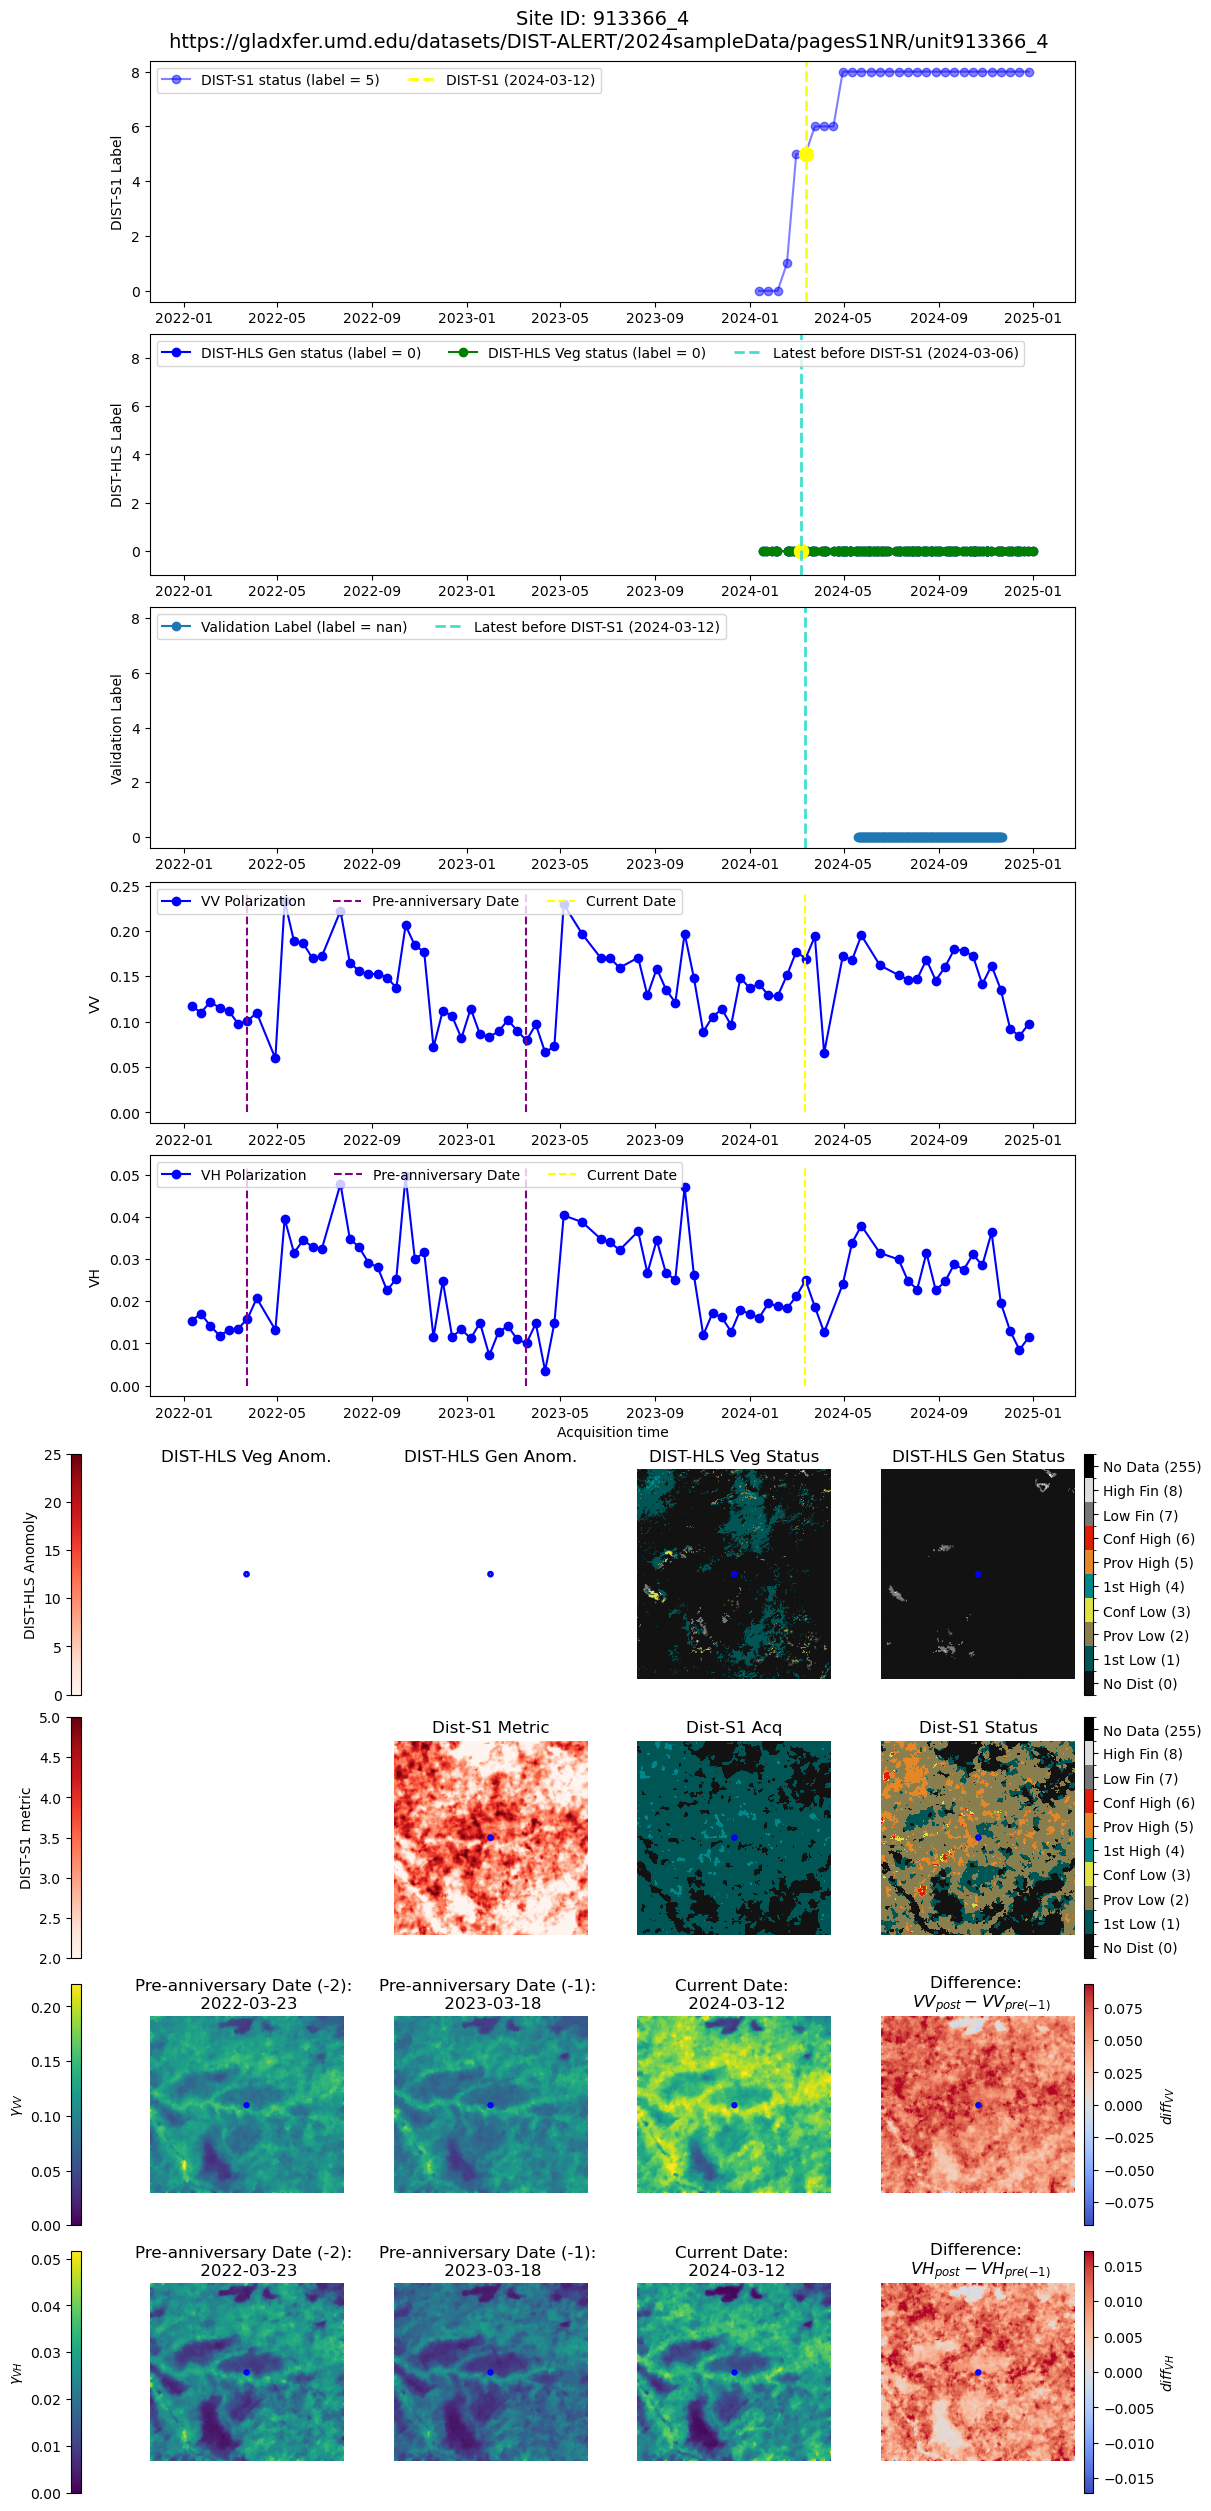

In [83]:
f, _ = create_plot_panel(5)

In [84]:
for k in tqdm(range(len(dist_s1_dates))):
    f, _ = create_plot_panel(k)
    f.savefig(png_dir / f'panel_{k}.png')
    plt.close('all')

  0%|          | 0/30 [00:00<?, ?it/s]

pre_index=29
post_index=56


  3%|▎         | 1/30 [00:01<00:29,  1.03s/it]

pre_index=30
post_index=57


  7%|▋         | 2/30 [00:01<00:25,  1.08it/s]

...

 93%|█████████▎| 28/30 [00:24<00:01,  1.16it/s]

pre_index=54
post_index=81


 97%|█████████▋| 29/30 [00:25<00:00,  1.17it/s]

pre_index=55
post_index=82


100%|██████████| 30/30 [00:26<00:00,  1.13it/s]


In [85]:
def sorter(path: Path):
    fn = path.stem
    if 'panel' in fn:
        return int(fn.split('_')[1])
    else:
        return -1

png_imgs = sorted(list(png_dir.glob('*.png')), key=sorter)
png_imgs[:3]

[PosixPath('out/913366_4/pngs/_location.png'),
 PosixPath('out/913366_4/pngs/panel_0.png'),
 PosixPath('out/913366_4/pngs/panel_1.png')]

In [86]:
with open(site_dir / f'ts_{SITE_ID}.pdf', "wb") as f:
    f.write(img2pdf.convert(png_imgs))

Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.


Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an alpha channel. Computing a separate soft mask (/SMask) image to store transparency in PDF.
Image contains an a